In [1]:
import pyspark                                            
print('pyspark: %s' % pyspark.__version__)                 
from pyspark.sql import SparkSession                      
from pyspark.sql import functions as F                     
from pyspark.ml.feature import VectorAssembler, StandardScaler   
from pyspark.ml.functions import vector_to_array           
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'                   
import tensorflow as tf                                    
import keras                                               
print('Tensorflow: %s | Keras: %s' % (tf.__version__, keras.__version__))   # print versions
import numpy as np                                         
print('numpy: %s' % np.__version__)                        
import pandas as pd                                        
print('pandas: %s' % pd.__version__)                       
import matplotlib.pyplot as plt                            
import seaborn as sns                                      
print('seaborn: %s' % sns.__version__)                     
import time                                                
import json                                                

pyspark: 4.2.0
Tensorflow: 2.21.0 | Keras: 3.15.1
numpy: 2.5.3
pandas: 2.3.3
seaborn: 0.13.2


In [2]:
# Plot and display settings used in every notebook
def jupyter_settings():
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.rcParams.update({
        'figure.figsize': (12, 6),
        'figure.dpi': 100,
        'axes.titlesize': 14,
        'axes.labelsize': 12,
        'legend.fontsize': 10,
        'xtick.labelsize': 10,
        'ytick.labelsize': 10,
        'savefig.bbox': 'tight',
        'savefig.dpi': 120
    })
    pd.set_option('display.max_columns', 30)
    pd.set_option('display.float_format', '{:,.2f}'.format)

jupyter_settings()

In [3]:
##### Specify parameters
SEED = 1234              # seed used for every random choice in the project
TRAIN_BUCKETS = 200      # keeps 20% of the training split (bucket < 200), the same trips at every level
EVAL_BUCKETS = 200       # keeps 20% of validation and test
STORAGE_LEVELS = ['L0_native', 'L1_float32', 'D1_dist_1dec', 'D0_dist_0dec', 'T1_ts_1min', 'T15_ts_15min']

##### Create the Spark session
spark = (SparkSession.builder
         .master('local[2]')                                               # 2 parallel tasks: with 4 the VM crashed under memory pressure
         .appName('ca1-03-nn-design')
         .config('spark.driver.memory', '2g')                              # leaves room for HDFS, the OS and TensorFlow
         .config('spark.sql.session.timeZone', 'UTC')                      # avoids the Dublin DST shift on 31/03 with timestamp_ntz
         .config('spark.local.dir', os.path.expanduser('~/spark-tmp'))     
         .getOrCreate())


# Paths 
BASE = 'hdfs://localhost:9000/ca1'
LEVELS_OUT = f'{BASE}/levels'                                  # train/ versions written in notebook 02
NN_DIR = os.path.expanduser('~/ca1/data/nn')                   # local disk: the extracts are read by pandas and TensorFlow, not by Spark
RESULTS = os.path.expanduser('~/ca1/results')
FIGURES = os.path.expanduser('~/ca1/figures')
for folder in [NN_DIR, RESULTS, FIGURES]:
    os.makedirs(folder, exist_ok=True)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/10/01 21:09:41 WARN Utils: Your hostname, BDSP, resolves to a loopback address: 127.0.1.1; using 10.0.2.15 instead (on interface enp0s3)
26/10/01 21:09:41 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/10/01 21:09:42 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/10/01 21:09:42 WARN SparkConf: Note that spark.local.dir will be overridden by the value set by the cluster manager (via SPARK_LOCAL_DIRS in standalone/kubernetes and LOCAL_DIRS in YARN).


In [4]:
# Build the features in Spark for every storage level and write a small extract to the local disk
for name in STORAGE_LEVELS:
    df = spark.read.parquet(f'{LEVELS_OUT}/train/{name}')

    # Keep 20% of each split, selected by the hash bucket, so every level has exactly the same trips
    df = df.filter(((df['split'] == 'train') & (df['bucket'] < TRAIN_BUCKETS)) |
                   ((df['split'] != 'train') & (df['bucket'] < EVAL_BUCKETS)))

    # Time features from the (possibly truncated) pickup timestamp
    pickup = df['tpep_pickup_datetime']
    hour = F.hour(pickup) + F.minute(pickup) / 60 + F.second(pickup) / 3600       # hour of the day as a decimal, 0 to 24
    df = (df.withColumn('dist', df['trip_distance'].cast('double'))               # float32 level is read back as double
            .withColumn('hour_sin', F.sin(2 * np.pi * hour / 24))                  # cyclic encoding: 23:59 and 00:00 end up close
            .withColumn('hour_cos', F.cos(2 * np.pi * hour / 24))
            .withColumn('dow', F.dayofweek(pickup) - 1)                            # day of week, 0 = Sunday
            .withColumn('label_ts', F.unix_timestamp(df['tpep_dropoff_datetime']) - F.unix_timestamp(pickup)))   # duration from the stored timestamps (lossy at T levels)

    # Scale the numeric features with Spark ML, fitted on the training split only (no information from validation or test)
    assembler = VectorAssembler(inputCols=['dist', 'hour_sin', 'hour_cos'], outputCol='num_vec')
    df = assembler.transform(df)
    scaler = StandardScaler(inputCol='num_vec', outputCol='num_scaled', withMean=True, withStd=True)
    scaler_model = scaler.fit(df.filter(df['split'] == 'train'))
    df = scaler_model.transform(df).withColumn('num', vector_to_array('num_scaled'))

    # Write the extract with only the columns the network needs
    df_out = df.select('trip_id', 'split',
                       df['num'][0].alias('dist_z'), df['num'][1].alias('hour_sin_z'), df['num'][2].alias('hour_cos_z'),
                       'dow', 'PULocationID', 'DOLocationID', 'duration_s_true', 'label_ts')
    df_out.write.mode('overwrite').parquet(f'file://{NN_DIR}/{name}')
    print(name, {r['split']: r['count'] for r in df_out.groupBy('split').count().collect()})

L0_native {'train': 1153739, 'validation': 335812, 'test': 354160}


L1_float32 {'train': 1153739, 'validation': 335812, 'test': 354160}


D1_dist_1dec {'train': 1153739, 'validation': 335812, 'test': 354160}


D0_dist_0dec {'train': 1153739, 'validation': 335812, 'test': 354160}


T1_ts_1min {'train': 1153739, 'validation': 335812, 'test': 354160}


T15_ts_15min {'train': 1153739, 'validation': 335812, 'test': 354160}


In [5]:
# Stop Spark before TensorFlow starts training: the VM cannot hold both in memory
spark.stop()

In [6]:
##### Specify parameters
Y_SCALE = 600.0          # target in units of 10 minutes, keeps the loss in a stable range for Adam
BATCH = 1024             # samples per gradient update
EPOCHS = 100             # upper limit only: early stopping decides the real number of epochs
PATIENCE = 5             # epochs without improvement in validation loss before stopping

keras.utils.set_random_seed(SEED)                  # seeds Python, NumPy and TensorFlow at once
tf.config.experimental.enable_op_determinism()     # same seed, same result: the run can be repeated in front of an examiner

# Read an extract and split it into train, validation and test
def load_level(name):
    data = pd.read_parquet(f'{NN_DIR}/{name}')
    data = data.sort_values('trip_id').reset_index(drop=True)      # same row order at every level, so the same seed gives the same batches
    return {s: data[data['split'] == s].reset_index(drop=True) for s in ['train', 'validation', 'test']}

data_l0 = load_level('L0_native')
for s in ['train', 'validation', 'test']:
    print(f'{s:11}', data_l0[s].shape)

# Show a snapshot of data
data_l0['train'].head(3)

train       (1153739, 10)
validation  (335812, 10)
test        (354160, 10)


,trip_id,split,dist_z,hour_sin_z,hour_cos_z,dow,PULocationID,DOLocationID,duration_s_true,label_ts
0,0,train,-0.70,0.51,1.61,1,140,140,169,169
1,3,train,1.01,0.52,1.61,1,125,157,1348,1348
2,9,train,3.84,0.52,1.61,1,132,262,1467,1467


In [7]:
# Turn a dataframe into the inputs of the network
def to_inputs(data, zone_mode):
    num = data[['dist_z', 'hour_sin_z', 'hour_cos_z']].to_numpy('float32')
    dow = np.eye(7, dtype='float32')[data['dow'].to_numpy()]                 # one-hot day of week
    if zone_mode == 'numeric':
        zones = data[['PULocationID', 'DOLocationID']].to_numpy('float32') / 265.0   # zone ids as plain numbers (phase 1 only)
        return {'Input-Numeric': np.hstack([num, dow, zones])}
    return {'Input-Numeric': np.hstack([num, dow]),
            'Input-PU-Zone': data['PULocationID'].to_numpy('int32'),
            'Input-DO-Zone': data['DOLocationID'].to_numpy('int32')}

# Build and compile the network
def build_model(zone_mode='embedding', hidden=(64, 32), dropout=0.0, emb_dim=8, lr=1e-3):
    n_num = 12 if zone_mode == 'numeric' else 10                                       
    num_in = keras.Input(shape=(n_num,), name='Input-Numeric')                        # Input Layer for the numeric features
    inputs, parts = [num_in], [num_in]
    if zone_mode == 'embedding':
        pu_in = keras.Input(shape=(), dtype='int32', name='Input-PU-Zone')            # Input Layer for the pickup zone id
        do_in = keras.Input(shape=(), dtype='int32', name='Input-DO-Zone')            # Input Layer for the dropoff zone id
        zone_emb = keras.layers.Embedding(input_dim=266, output_dim=emb_dim, name='Zone-Embedding')   # one shared table: a zone means the same as origin or destination
        parts += [zone_emb(pu_in), zone_emb(do_in)]
        inputs += [pu_in, do_in]
    x = keras.layers.Concatenate(name='Concatenate-Layer')(parts)                     # joins all inputs in one vector
    for i, units in enumerate(hidden, start=1):
        x = keras.layers.Dense(units, activation='relu', name=f'Hidden-Layer-{i}')(x) # Hidden Layer
        if dropout > 0:
            x = keras.layers.Dropout(dropout, name=f'Dropout-Layer-{i}')(x)          # randomly switches off a fraction of neurons during training
    out = keras.layers.Dense(1, activation='linear', name='Output-Layer')(x)          # Output Layer, Linear(x) = x, one value: the duration
    model = keras.Model(inputs=inputs, outputs=out, name='MLP-Duration-Model')

    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),   # algorithm used in backpropagation; default learning rate 0.001
                  loss='mean_squared_error',                           # loss function to be optimized
                  metrics=['mean_absolute_error'])                     # metric reported every epoch, in units of Y_SCALE
    return model

# Train one configuration and score it against the real duration
def train_eval(data, cfg, seed, label='duration_s_true', n_train=None, eval_split='validation'):
    keras.utils.set_random_seed(seed)
    train = data['train'] if n_train is None else data['train'].iloc[:n_train]
    X_train, y_train = to_inputs(train, cfg['zone_mode']), train[label].to_numpy('float32') / Y_SCALE
    X_val, y_val = to_inputs(data['validation'], cfg['zone_mode']), data['validation'][label].to_numpy('float32') / Y_SCALE   # label as training
    model = build_model(**{k: v for k, v in cfg.items() if k in ('zone_mode', 'hidden', 'dropout', 'emb_dim', 'lr')})
    early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True)   # keeps the weights of the best validation epoch

    t0 = time.perf_counter()
    history = model.fit(x=X_train,                          # input data
                        y=y_train,                          # target data
                        batch_size=BATCH,                   # number of samples per gradient update
                        epochs=EPOCHS,                      # upper limit ; early stopping ends the training before
                        verbose=0,                          # silent; one summary line is printed after training
                        callbacks=[early_stop],             # list of callbacks applied during training
                        validation_data=(X_val, y_val),     # temporal validation split (1 to 15 March)
                        shuffle=True)                       # reshuffles the training rows every epoch (controlled by the seed)
    train_s = time.perf_counter() - t0

    ev = data[eval_split]
    pred = model.predict(to_inputs(ev, cfg['zone_mode']), batch_size=8192, verbose=0).ravel() * Y_SCALE
    y_true = ev['duration_s_true'].to_numpy('float64')     # always scored against the real duration
    err = pred - y_true
    mse = (err ** 2).mean()
    res = {'MAE': np.abs(err).mean(), 'MSE': mse, 'RMSE': np.sqrt(mse),
           'R2': 1 - (err ** 2).sum() / ((y_true - y_true.mean()) ** 2).sum(),
           'Epochs': len(history.history['loss']), 'Train s': train_s}
    return res, history.history, model

# Plot training and validation MAE per epoch, in seconds
def plot_history(hist, title, filename):
    plt.figure(figsize=(12, 5))
    plt.plot(np.array(hist['mean_absolute_error']) * Y_SCALE, label='Training MAE')
    plt.plot(np.array(hist['val_mean_absolute_error']) * Y_SCALE, label='Validation MAE')
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('MAE (seconds)')
    plt.legend()
    plt.savefig(f'{FIGURES}/{filename}')
    plt.show()

In [8]:
# Baseline 1: predict the median training duration for every trip
y_val = data_l0['validation']['duration_s_true'].to_numpy('float64')
median_pred = data_l0['train']['duration_s_true'].median()

# Baseline 2: straight line on distance only (least squares)
slope, intercept = np.polyfit(data_l0['train']['dist_z'], data_l0['train']['duration_s_true'], 1)
line_pred = slope * data_l0['validation']['dist_z'].to_numpy() + intercept

# Score both baselines with the same metrics as the network
phase_results = []
for name, pred in [('Baseline median', np.full_like(y_val, median_pred)), ('Baseline linear (distance)', line_pred)]:
    err = pred - y_val
    phase_results.append([name, np.abs(err).mean(), (err ** 2).mean(), np.sqrt((err ** 2).mean()),
                          1 - (err ** 2).sum() / ((y_val - y_val.mean()) ** 2).sum(), np.nan, np.nan])

pd.DataFrame(phase_results, columns=['Phase', 'MAE', 'MSE', 'RMSE', 'R2', 'Epochs', 'Train s'])

,Phase,MAE,MSE,RMSE,R2,Epochs,Train s
0,Baseline median,506.28,"664,011.87",814.87,-0.10,NaN,NaN
1,Baseline linear (distance),307.39,"224,968.58",474.31,0.63,NaN,NaN


In [9]:
# Configurations of the three phases; each one changes a single thing from the previous one
PHASES = {
    'P1': {'zone_mode': 'numeric'},                    # zones as plain numbers
    'P2': {'zone_mode': 'embedding'},                  # only change: zone embeddings
    'P3': {'zone_mode': 'embedding', 'dropout': 0.2},  # only change: dropout 0.2 (Srivastava et al., 2014)
}

Phase 1 | MAE 216.1 s | RMSE 373.1 s | R2 0.7685 | epochs 65 | 697 s


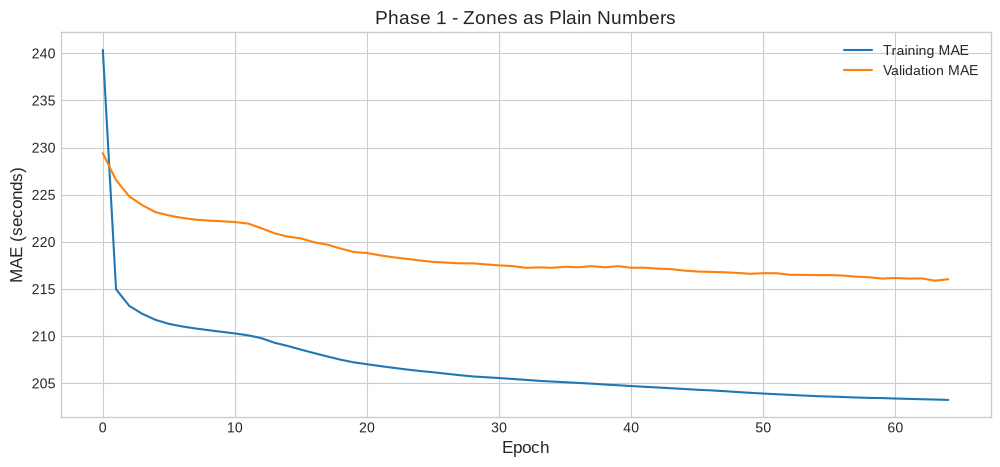

In [10]:
##### Phase 1 - Zones as plain numbers
res_p1, hist_p1, model_p1 = train_eval(data_l0, PHASES['P1'], SEED)
phase_results.append(['P1 zones as numbers', *res_p1.values()])
print(f"Phase 1 | MAE {res_p1['MAE']:.1f} s | RMSE {res_p1['RMSE']:.1f} s | R2 {res_p1['R2']:.4f} | epochs {res_p1['Epochs']} | {res_p1['Train s']:.0f} s")
plot_history(hist_p1, 'Phase 1 - Zones as Plain Numbers', '03_phase1_history.png')

P2 | MAE 177.5 s | RMSE 314.5 s | R2 0.8355 | epochs 36 | 379 s


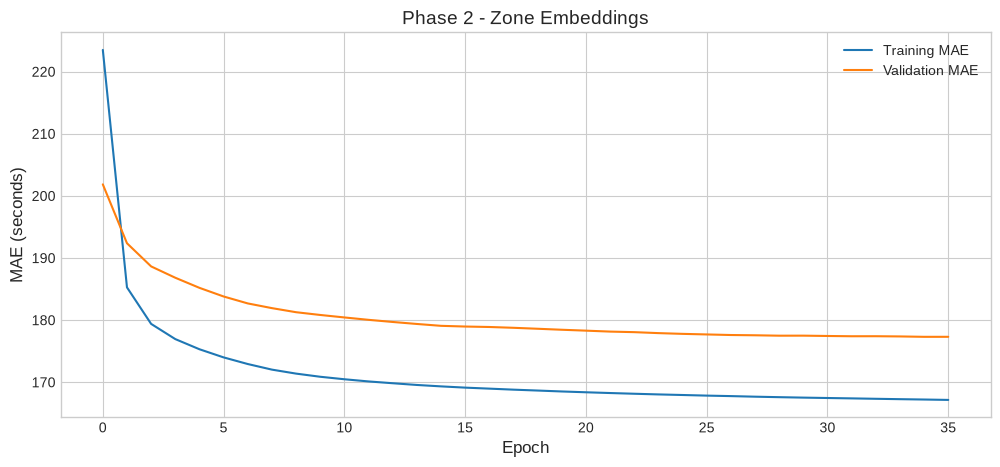

In [11]:
##### Phase 2 - Zone embeddings
res_p2, hist_p2, model_p2 = train_eval(data_l0, PHASES['P2'], SEED)
phase_results.append(['P2 zone embeddings', *res_p2.values()])
print(f"P2 | MAE {res_p2['MAE']:.1f} s | RMSE {res_p2['RMSE']:.1f} s | R2 {res_p2['R2']:.4f} | epochs {res_p2['Epochs']} | {res_p2['Train s']:.0f} s")
plot_history(hist_p2, 'Phase 2 - Zone Embeddings', '03_phase2_history.png')

P3 | MAE 196.8 s | RMSE 332.2 s | R2 0.8165 | epochs 13 | 167 s


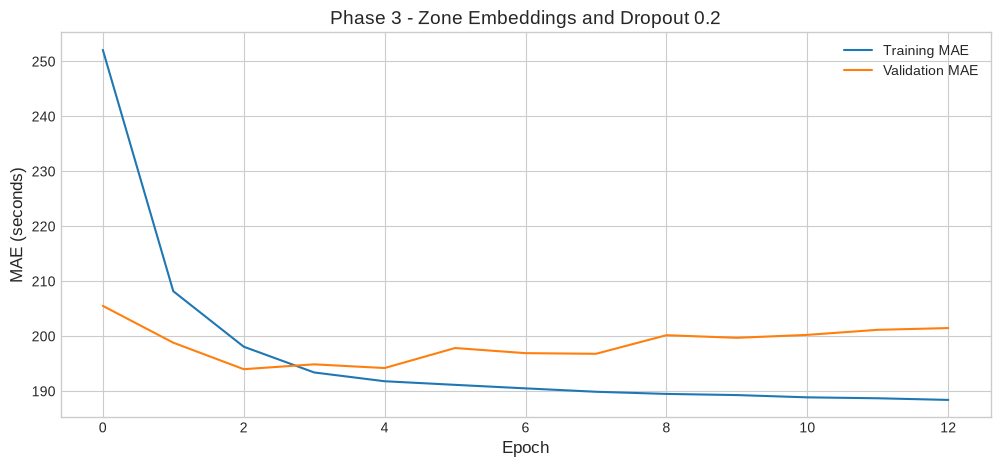

In [12]:
##### Phase 3 - Dropout 0.2
res_p3, hist_p3, model_p3 = train_eval(data_l0, PHASES['P3'], SEED)
phase_results.append(['P3 embeddings + dropout 0.2', *res_p3.values()])
print(f"P3 | MAE {res_p3['MAE']:.1f} s | RMSE {res_p3['RMSE']:.1f} s | R2 {res_p3['R2']:.4f} | epochs {res_p3['Epochs']} | {res_p3['Train s']:.0f} s")
plot_history(hist_p3, 'Phase 3 - Zone Embeddings and Dropout 0.2', '03_phase3_history.png')

In [13]:
# Results of the baselines and all phases on the validation split
phase_results_df = pd.DataFrame(phase_results, columns=['Phase', 'MAE', 'MSE', 'RMSE', 'R2', 'Epochs', 'Train s'])
phase_results_df.to_csv(f'{RESULTS}/03_phases.csv', index=False)
phase_results_df

,Phase,MAE,MSE,RMSE,R2,Epochs,Train s
0,Baseline median,506.28,"664,011.87",814.87,-0.10,NaN,NaN
1,Baseline linear (distance),307.39,"224,968.58",474.31,0.63,NaN,NaN
2,P1 zones as numbers,216.12,"139,229.28",373.13,0.77,65.00,697.24
3,P2 zone embeddings,177.45,"98,938.96",314.55,0.84,36.00,379.43
4,P3 embeddings + dropout 0.2,196.81,"110,357.65",332.20,0.82,13.00,166.59


In [14]:
# Keep the phase with the lowest validation MAE as the final architecture
phase_mae = {'P1': res_p1['MAE'], 'P2': res_p2['MAE'], 'P3': res_p3['MAE']}
BEST_PHASE = min(phase_mae, key=phase_mae.get)
FINAL = PHASES[BEST_PHASE]
print('Best phase:', BEST_PHASE, '| configuration:', FINAL)

Best phase: P2 | configuration: {'zone_mode': 'embedding'}


In [15]:
# Train the final architecture on growing fractions of the training sample
FRACTIONS = [0.05, 0.10, 0.25, 0.50, 1.00]
n_full = len(data_l0['train'])
lc_results = []
for frac in FRACTIONS:
    n = int(n_full * frac)
    res, _, _ = train_eval(data_l0, FINAL, SEED, n_train=n)     # early stopping at every size, so small samples are not under-trained
    lc_results.append([frac, n, res['MAE'], res['RMSE'], res['Epochs'], res['Train s']])
    print(f"{frac:5.0%} | {n:>9,} trips | MAE {res['MAE']:.1f} s | epochs {res['Epochs']} | {res['Train s']:.0f} s")

lc_df = pd.DataFrame(lc_results, columns=['Fraction', 'Training trips', 'MAE', 'RMSE', 'Epochs', 'Train s'])
lc_df.to_csv(f'{RESULTS}/03_learning_curve.csv', index=False)
lc_df

   5% |    57,686 trips | MAE 302.9 s | epochs 11 | 24 s
  10% |   115,373 trips | MAE 220.2 s | epochs 40 | 106 s
  25% |   288,434 trips | MAE 201.5 s | epochs 64 | 1352 s
  50% |   576,869 trips | MAE 185.6 s | epochs 39 | 572 s
 100% | 1,153,739 trips | MAE 177.5 s | epochs 36 | 373 s


,Fraction,Training trips,MAE,RMSE,Epochs,Train s
0,0.05,57686,302.93,473.43,11,24.00
1,0.10,115373,220.20,389.91,40,106.32
2,0.25,288434,201.54,358.20,64,"1,352.00"
3,0.50,576869,185.62,330.72,39,572.40
4,1.00,1153739,177.45,314.55,36,373.36


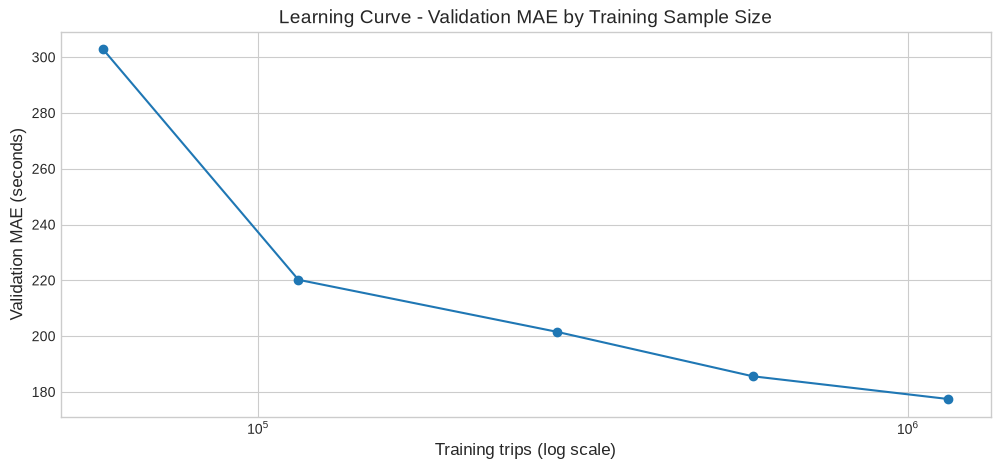

In [16]:
# Plot the learning curve
plt.figure(figsize=(12, 5))
plt.plot(lc_df['Training trips'], lc_df['MAE'], marker='o')
plt.xscale('log')                                                # log scale: each point doubles or more the previous sample
plt.title('Learning Curve - Validation MAE by Training Sample Size')
plt.xlabel('Training trips (log scale)')
plt.ylabel('Validation MAE (seconds)')
plt.savefig(f'{FIGURES}/03_learning_curve.png')
plt.show()

In [17]:
# Freeze the final configuration for notebook 04
frozen = {'final_config': FINAL, 'best_phase': BEST_PHASE, 'seed': SEED, 'train_buckets': TRAIN_BUCKETS,
          'eval_buckets': EVAL_BUCKETS, 'y_scale': Y_SCALE, 'batch': BATCH, 'epochs': EPOCHS, 'patience': PATIENCE}
with open(f'{RESULTS}/03_final_config.json', 'w') as f:
    json.dump(frozen, f, indent=2)

# Print Performance Summary of the final architecture
print('-------------------- Model Summary --------------------')
build_model(**FINAL).summary()
print(json.dumps(frozen, indent=2))

-------------------- Model Summary --------------------


Model: "MLP-Duration-Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Input-PU-Zone       │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Input-DO-Zone       │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Input-Numeric       │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Zone-Embedding      │ (None, 8)         │      2,128 │ Input-PU-Zone[0]… │
│ (Embedding)         │                   │            │ Input-DO-Zone[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Concatenate-Layer   │ (None, 26)        │          0 │ Input-Numeric[0]… │
│ (Concatenate)       │                   │            │ Zone-Embedding[0… │
│                     │                   │            │ Zone-Embedding[1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Hidden-Layer-1      │ (None, 64)        │      1,728 │ Concatenate-Laye… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Hidden-Layer-2      │ (None, 32)        │      2,080 │ Hidden-Layer-1[0… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Output-Layer        │ (None, 1)         │         33 │ Hidden-Layer-2[0… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,969 (23.32 KB)

 Trainable params: 5,969 (23.32 KB)

 Non-trainable params: 0 (0.00 B)

{
  "final_config": {
    "zone_mode": "embedding"
  },
  "best_phase": "P2",
  "seed": 1234,
  "train_buckets": 200,
  "eval_buckets": 200,
  "y_scale": 600.0,
  "batch": 1024,
  "epochs": 100,
  "patience": 5
}
